In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [11]:
from pathlib import Path
import pandas as pd

BASE_DIR = Path("/Users/vayu/Desktop/revenue-leak-detector") #replace this path with your own
DATA_DIR = BASE_DIR / "data" / "raw"

accounts      = pd.read_csv(DATA_DIR / "accounts.csv")
deals         = pd.read_csv(DATA_DIR / "deals.csv")
usage         = pd.read_csv(DATA_DIR / "product_usage.csv")
tickets       = pd.read_csv(DATA_DIR / "support_tickets.csv")
sales_notes   = pd.read_csv(DATA_DIR / "sales_notes.csv")
cancellations = pd.read_csv(DATA_DIR / "cancellations.csv")

In [12]:
head(accounts)


NameError: name 'head' is not defined

In [13]:
accounts.head()

,account_id,company_size,industry,region,plan_type,signup_date,monthly_revenue
0,A00001,small_business,tech_startup,Asia,pro,2025-10-16,12
1,A00002,solo,ecommerce,North America,pro,2024-01-26,36
2,A00003,small_business,media,North America,team,2024-09-07,90
3,A00004,mid_market,ecommerce,North America,pro,2024-05-22,12
4,A00005,solo,education,North America,free,2025-11-23,0


In [14]:
print(accounts.shape)
print(deals.shape)
print(usage.shape)
print(tickets.shape)
print(sales_notes.shape)
print(cancellations.shape)

(2000, 7)
(5000, 10)
(29370, 8)
(2763, 9)
(8995, 5)
(214, 8)


In [15]:
accounts.head()
deals.head()

,deal_id,account_id,lead_source,created_date,deal_value,discount_pct,competitor_mentioned,stage,close_date,deal_status
0,D00001,A00670,referral,2026-01-30,480,15,Canva,demo,2026-02-10,won
1,D00002,A01490,outbound,2025-05-15,180,0,Canva,negotiation,2025-06-23,lost
2,D00003,A01898,website,2025-07-04,720,20,Figma,demo,2025-07-21,won
3,D00004,A01675,website,2025-05-11,240,0,Adobe Express,demo,2025-05-18,lost
4,D00005,A00221,website,2025-01-23,60,0,Canva,demo,2025-02-23,lost


In [21]:
#Inspecting for missing values
for name, df in {
    "accounts": accounts,
    "deals": deals,
    "usage": usage,
    "tickets": tickets,
    "sales_notes": sales_notes,
    "cancellations": cancellations,
}.items():
    print(f"\n{name}")
    print(df.isna().sum())


accounts
account_id         0
company_size       0
industry           0
region             0
plan_type          0
signup_date        0
monthly_revenue    0
dtype: int64

deals
deal_id                    0
account_id                 0
lead_source                0
created_date               0
deal_value                 0
discount_pct               0
competitor_mentioned    1007
stage                      0
close_date                 0
deal_status                0
dtype: int64

usage
account_id                0
week_start                0
projects_created          0
templates_used            0
ai_design_tool_usage      0
exports_count             0
collaboration_sessions    0
weekly_active_users       0
dtype: int64

tickets
ticket_id           0
account_id          0
created_date        0
ticket_type         0
priority            0
resolution_hours    0
csat_score          0
ticket_summary      0
account_revenue     0
dtype: int64

sales_notes
note_id       0
deal_id       0
account_id 

In [22]:
deals["competitor_mentioned"].value_counts(dropna=False).head()

competitor_mentioned
Canva            1946
Adobe Express    1150
NaN              1007
Figma             501
Piktochart        396
Name: count, dtype: int64

In [24]:
#Convert date columns
accounts["signup_date"] = pd.to_datetime(accounts["signup_date"])
deals["created_date"] = pd.to_datetime(deals["created_date"])
deals["close_date"] = pd.to_datetime(deals["close_date"])
usage["week_start"] = pd.to_datetime(usage["week_start"])
tickets["created_date"] = pd.to_datetime(tickets["created_date"])
sales_notes["note_date"] = pd.to_datetime(sales_notes["note_date"])
cancellations["cancellation_date"] = pd.to_datetime(cancellations["cancellation_date"])

In [25]:
accounts["plan_type"].value_counts()

plan_type
pro     905
free    583
team    512
Name: count, dtype: int64

In [26]:
accounts["company_size"].value_counts()

company_size
small_business    882
solo              719
mid_market        399
Name: count, dtype: int64

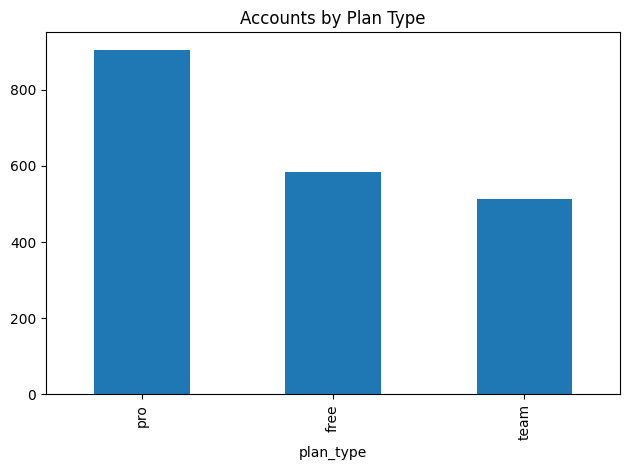

In [29]:
#trying to understand the customer base
accounts["plan_type"].value_counts().plot(kind="bar", title="Accounts by Plan Type")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "accounts_by_plan.png")
plt.show()

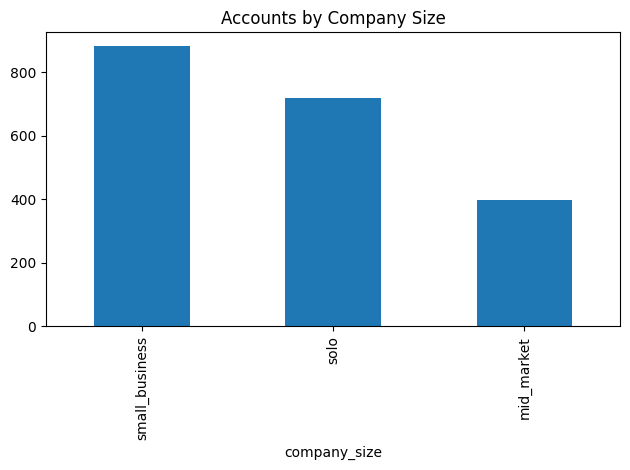

In [30]:
accounts["company_size"].value_counts().plot(kind="bar", title="Accounts by Company Size")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "accounts_by_size.png")
plt.show()

In [31]:
accounts["monthly_revenue"].describe()

count    2000.000000
mean       69.132000
std       107.530498
min         0.000000
25%         0.000000
50%        24.000000
75%        60.000000
max       450.000000
Name: monthly_revenue, dtype: float64

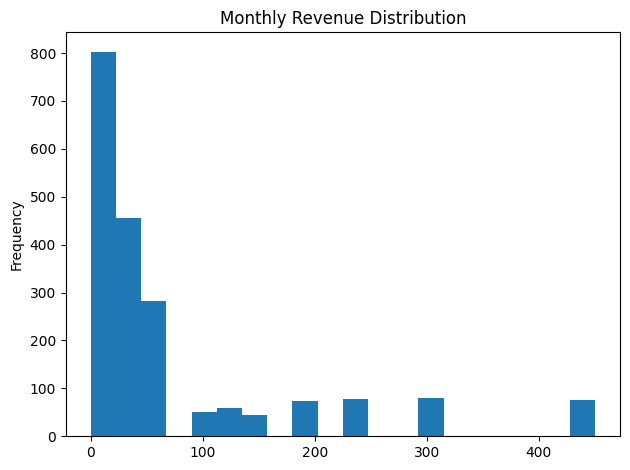

In [33]:
#seeing how monetization is spread across customers
accounts["monthly_revenue"].plot(kind="hist", bins=20, title="Monthly Revenue Distribution")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "monthly_revenue_distribution.png")
plt.show()

In [34]:
deals["deal_status"].value_counts()

deal_status
lost    2578
won     2422
Name: count, dtype: int64

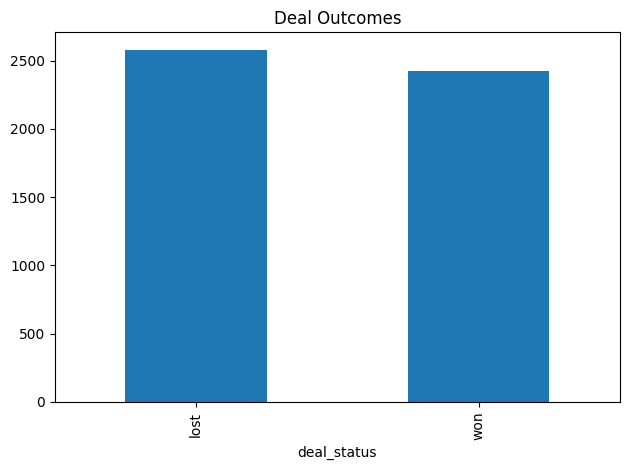

In [35]:
deals["deal_status"].value_counts().plot(kind="bar", title="Deal Outcomes")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "deal_outcomes.png")
plt.show()

In [37]:
#checing for the first revenue leak metric
lost_pipeline = deals.loc[deals["deal_status"] == "lost", "deal_value"].sum()
won_pipeline = deals.loc[deals["deal_status"] == "won", "deal_value"].sum()

print("Lost pipeline value:", lost_pipeline)
print("Won pipeline value:", won_pipeline)

Lost pipeline value: 1869900
Won pipeline value: 1538700


In [38]:
#competitor effect
deal_win_rates = (
    deals.assign(is_won=deals["deal_status"].eq("won").astype(int))
    .groupby("competitor_mentioned")["is_won"]
    .mean()
    .sort_values()
)

deal_win_rates

competitor_mentioned
Piktochart       0.462121
Canva            0.469681
Adobe Express    0.470435
Figma            0.483034
Name: is_won, dtype: float64

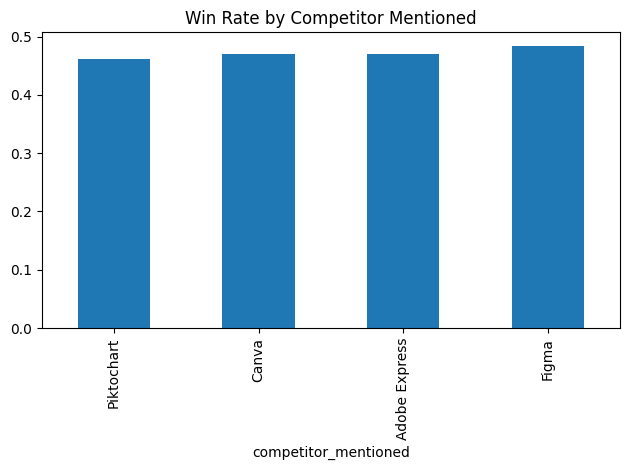

In [39]:
deal_win_rates.plot(kind="bar", title="Win Rate by Competitor Mentioned")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "win_rate_by_competitor.png")
plt.show()

In [40]:
#aggregate usage to account level:
usage_summary = (
    usage.groupby("account_id")[
        ["projects_created", "templates_used", "ai_design_tool_usage", "exports_count", "collaboration_sessions", "weekly_active_users"]
    ]
    .mean()
    .reset_index()
)

In [41]:
#merge with account info:
account_usage = accounts.merge(usage_summary, on="account_id", how="left")
account_usage.head()

,account_id,company_size,industry,region,plan_type,signup_date,monthly_revenue,projects_created,templates_used,ai_design_tool_usage,exports_count,collaboration_sessions,weekly_active_users
0,A00001,small_business,tech_startup,Asia,pro,2025-10-16,12,2.375000,5.1875,1.3750,1.8750,0.3750,2.375000
1,A00002,solo,ecommerce,North America,pro,2024-01-26,36,3.562500,6.6250,0.5625,3.0625,0.0000,1.000000
2,A00003,small_business,media,North America,team,2024-09-07,90,7.375000,8.3750,2.3750,7.3125,0.4375,2.375000
3,A00004,mid_market,ecommerce,North America,pro,2024-05-22,12,5.625000,8.5625,2.6250,5.1875,2.6250,12.812500
4,A00005,solo,education,North America,free,2025-11-23,0,1.533333,0.6000,0.0000,1.2000,0.0000,1.533333


In [42]:
#checking useage by plan:
account_usage.groupby("plan_type")[["projects_created", "weekly_active_users", "collaboration_sessions"]].mean()

,projects_created,weekly_active_users,collaboration_sessions
plan_type,,,
free,0.673354,1.952896,0.673489
pro,3.537605,3.790152,1.769736
team,7.535338,8.475273,4.611115


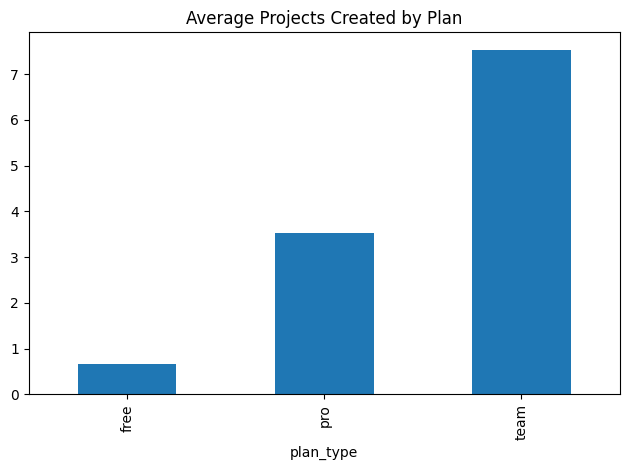

In [43]:
#chart one:
account_usage.groupby("plan_type")["projects_created"].mean().plot(
    kind="bar", title="Average Projects Created by Plan"
)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "avg_projects_by_plan.png")
plt.show()

In [44]:
#insight, higher plans actually use the product more


In [45]:
#checking volume by ticket type:
tickets["ticket_type"].value_counts()

ticket_type
bug                  829
feature_request      727
performance_issue    682
billing              525
Name: count, dtype: int64

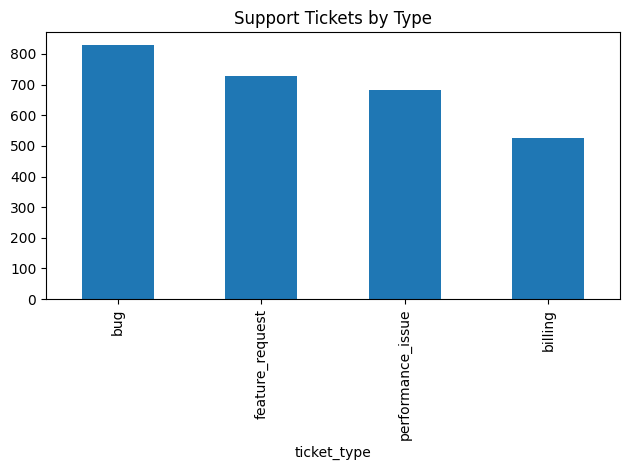

In [46]:
tickets["ticket_type"].value_counts().plot(kind="bar", title="Support Tickets by Type")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "tickets_by_type.png")
plt.show()

In [47]:
#checking average by CSAT type:
tickets.groupby("ticket_type")["csat_score"].mean().sort_values()

ticket_type
performance_issue    2.370968
bug                  3.268999
feature_request      3.348006
billing              3.382857
Name: csat_score, dtype: float64

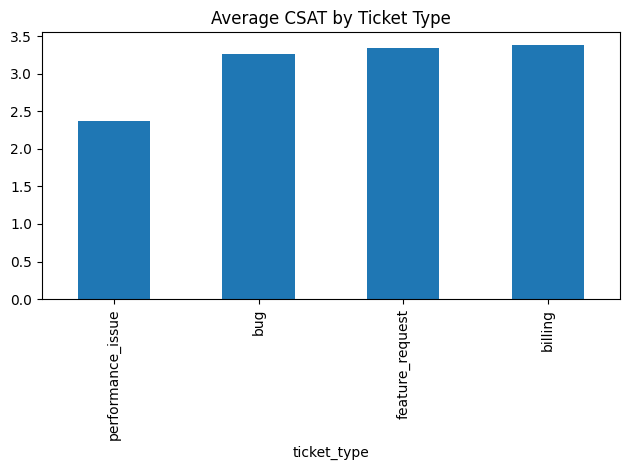

In [48]:
tickets.groupby("ticket_type")["csat_score"].mean().sort_values().plot(
    kind="bar", title="Average CSAT by Ticket Type"
)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "csat_by_ticket_type.png")
plt.show()

In [49]:
#check average resolution time by type:
tickets.groupby("ticket_type")["resolution_hours"].mean().sort_values()

ticket_type
billing              31.438095
bug                  32.670688
feature_request      32.888583
performance_issue    46.670088
Name: resolution_hours, dtype: float64

In [50]:
#performance issue hurts the support expereince the most

In [51]:
#churn overview:
len(cancellations)

214

In [52]:
cancellations["churned_revenue"].sum()

17262

In [53]:
cancellations["reason_type"].value_counts()

reason_type
competitor_switch    66
low_usage            63
pricing              48
performance          37
Name: count, dtype: int64

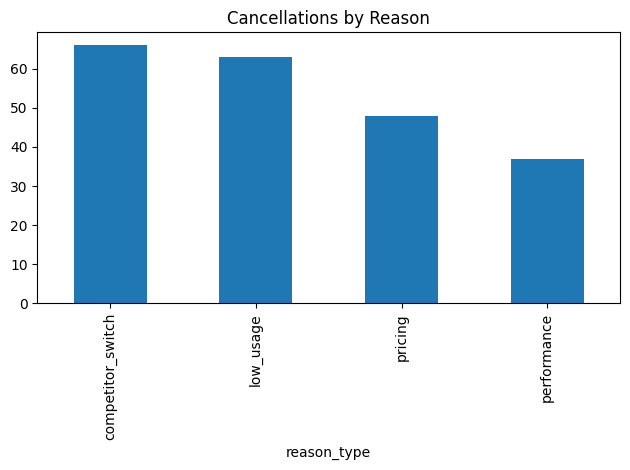

In [54]:
cancellations["reason_type"].value_counts().plot(kind="bar", title="Cancellations by Reason")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "cancellations_by_reason.png")
plt.show()

In [55]:
cancellations.groupby("reason_type")["churned_revenue"].sum().sort_values()

reason_type
performance          3606
pricing              3732
low_usage            3960
competitor_switch    5964
Name: churned_revenue, dtype: int64

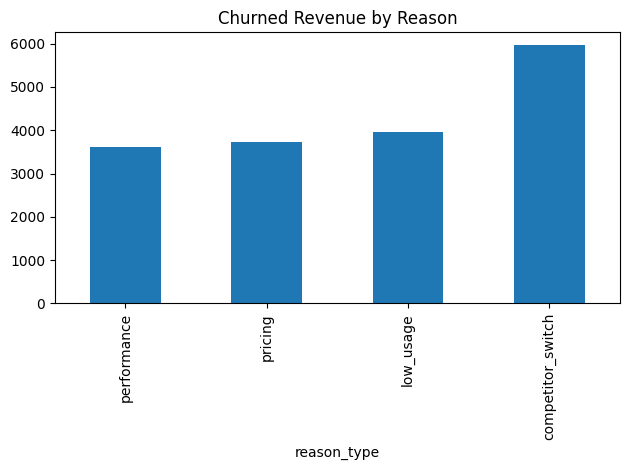

In [56]:
cancellations.groupby("reason_type")["churned_revenue"].sum().sort_values().plot(
    kind="bar", title="Churned Revenue by Reason"
)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "churned_revenue_by_reason.png")
plt.show()

In [57]:
#major revenue leak analysis. competitor switch is the biggest problem


In [58]:
#Analysis 8, Churn vs product useage:
account_usage["churned"] = account_usage["account_id"].isin(cancellations["account_id"]).astype(int)

In [59]:
account_usage.groupby("churned")[["projects_created", "weekly_active_users", "templates_used"]].mean()

,projects_created,weekly_active_users,templates_used
churned,,,
0,3.614951,4.434707,5.196096
1,4.619206,4.572234,7.028675


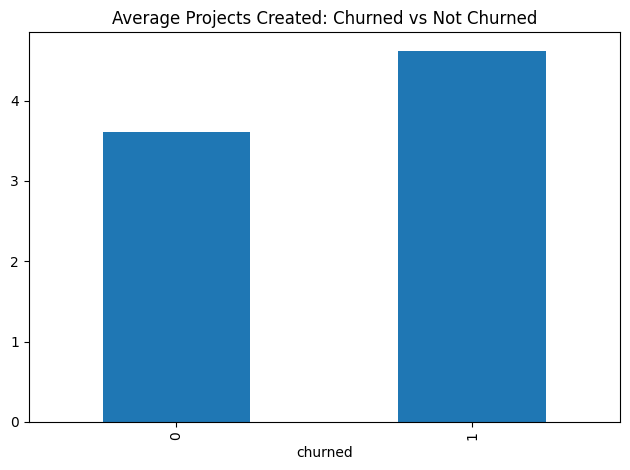

In [60]:
account_usage.groupby("churned")["projects_created"].mean().plot(
    kind="bar", title="Average Projects Created: Churned vs Not Churned"
)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "projects_created_churned_vs_not.png")
plt.show()

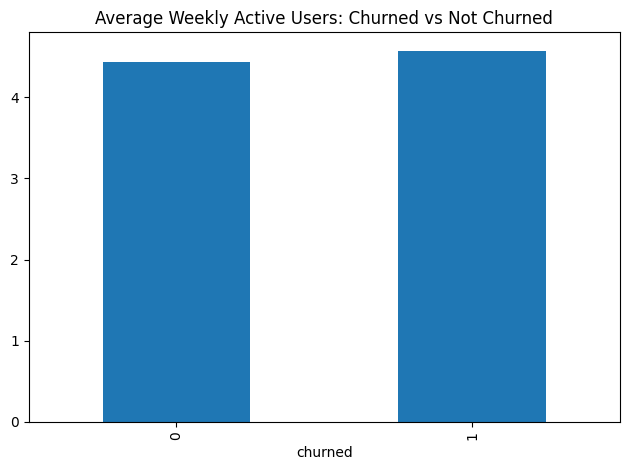

In [61]:
account_usage.groupby("churned")["weekly_active_users"].mean().plot(
    kind="bar", title="Average Weekly Active Users: Churned vs Not Churned"
)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "wau_churned_vs_not.png")
plt.show()

In [63]:
#aggregating tickets to account level:
ticket_summary = (
    tickets.groupby("account_id")
    .agg(
        ticket_count=("ticket_id", "count"),
        avg_resolution_hours=("resolution_hours", "mean"),
        avg_csat=("csat_score", "mean"),
    )
    .reset_index()
)

In [64]:
#Merging:
account_health = account_usage.merge(ticket_summary, on="account_id", how="left")
account_health[["ticket_count", "avg_resolution_hours", "avg_csat"]] = account_health[
    ["ticket_count", "avg_resolution_hours", "avg_csat"]
].fillna(0)

In [65]:
#compared churned vs not:
account_health.groupby("churned")[["ticket_count", "avg_resolution_hours", "avg_csat"]].mean()

,ticket_count,avg_resolution_hours,avg_csat
churned,,,
0,1.340426,22.662260,1.990163
1,1.724299,27.163095,2.221328


My findings so far:
- Accounts on Team plans generate the highest monthly revenue and also show the highest collaboration activity.
- Deals mentioning competitors have lower average win rates than deals with no competitor mentioned.
- Performance issues have the lowest CSAT among support ticket categories.
- Low usage is the most common churn reason in the synthetic dataset.
- Churned accounts show lower average project creation and fewer weekly active users than retained accounts.
- Accounts with more support tickets tend to show worse churn outcomes